[1]

In [7]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import TweedieRegressor
from tensorflow.keras.datasets import fashion_mnist

In [8]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [9]:
type(x_train),type(y_train),type(x_test),type(y_test)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

In [10]:
x_train.dtype,y_train.dtype,x_test.dtype,y_test.dtype

(dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'))

In [11]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [12]:
len(x_train) + len(x_test)

70000

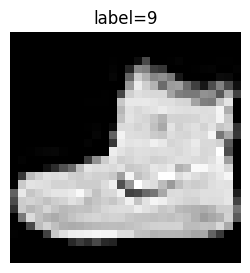

In [13]:
plt.figure(figsize=(3,3))
plt.imshow(x_train[0],cmap='gray')
plt.title('label='+str(y_train[0]))
plt.axis('off');

[2]

In [14]:
iris = datasets.load_iris(as_frame=True)
data = iris.frame
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [16]:
def accuracy(T,P,c=0):
    a = 0
    for i in range(len(T)):
        if T[i]==c and T[i]==P[i]:
            a += 1
    n = a/np.sum([(1 if e==c else 0) for e in T])
    m = a/np.sum([(1 if e==c else 0) for e in P])
    return 2*(n*m)/(n+m)

In [17]:
cols  = iris.feature_names
split = 0.2
train = list(np.random.choice(range(len(data)),int(len(data)*(1.0-split)),replace=False))
test  = list(set(range(len(data))).difference(set(train)))
len(train),len(test)

(120, 30)

In [18]:
Dtc = tree.DecisionTreeClassifier().fit(data.loc[train][cols],data.loc[train]['target'])
Dtc

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [19]:
true = np.asarray(data.loc[test]['target'])
pred = Dtc.predict(data.loc[test][cols])

acc = 0
for i in range(len(pred)):
    if pred[i]==true[i]:
        acc += 1
acc/len(pred)

0.9

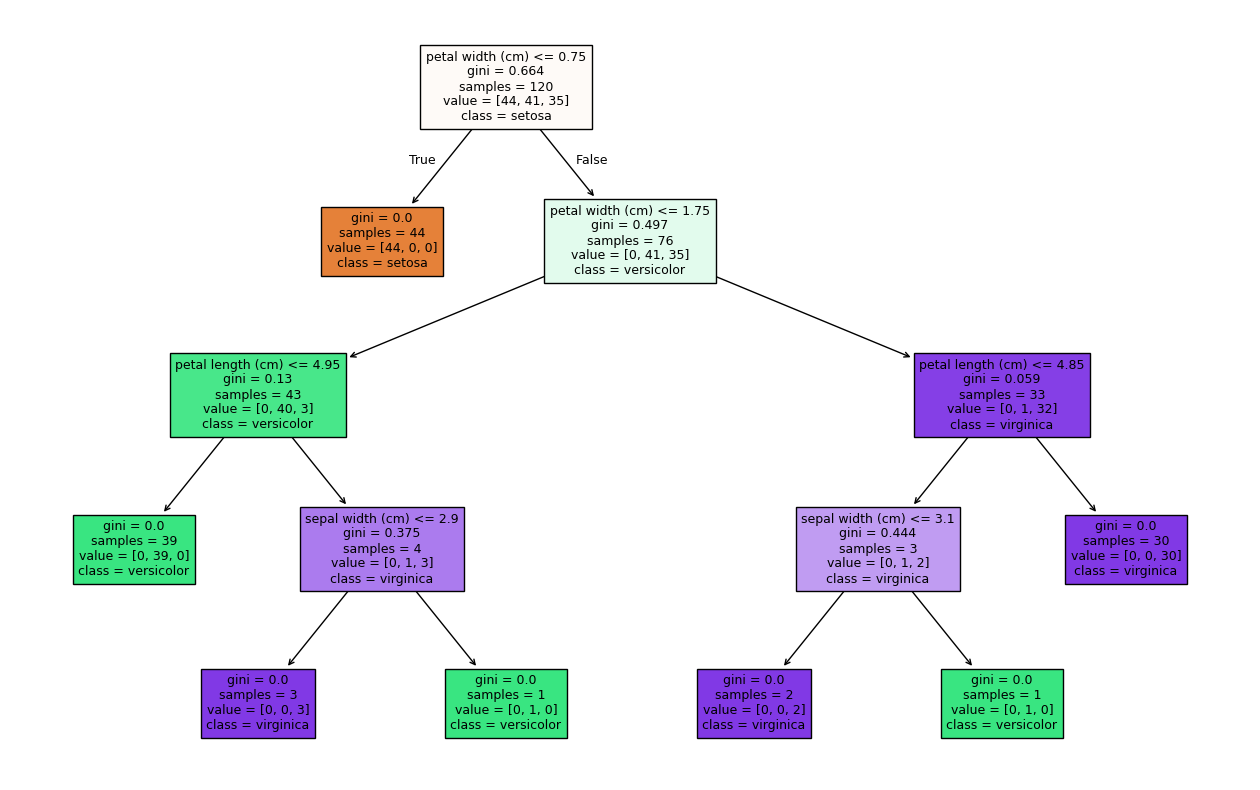

In [20]:
plt.figure(figsize=(16,10))
tree.plot_tree(Dtc,
               feature_names=cols,
               class_names=iris.target_names,
               filled=True,
               fontsize=9);

A decision tree works by asking a series of yes-or-no questions about the data. Each question splits the data into two groups. The tree keeps doing this until it reaches an end point, called a leaf, where it makes a prediction. For the iris data, the early splits separate the flower types that are easy to tell apart, and the later splits help with the flowers that are more similar.

[3]

In [21]:
xs_train = np.asarray([x.flatten() for x in x_train],dtype=np.uint8)
xs_test  = np.asarray([x.flatten() for x in x_test],dtype=np.uint8)

xs_train.shape,xs_test.shape

((60000, 784), (10000, 784))

In [23]:
Dtc = tree.DecisionTreeClassifier().fit(xs_train,y_train)
Dtc

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [24]:
pred = Dtc.predict(xs_test)

acc = 0
for i in range(len(pred)):
    if pred[i]==y_test[i]:
        acc += 1
acc/len(pred)

0.7918

In [25]:
pred[:20],y_test[:20]

(array([9, 2, 1, 1, 0, 1, 4, 6, 5, 7, 4, 5, 5, 3, 2, 1, 2, 4, 8, 0],
       dtype=uint8),
 array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0],
       dtype=uint8))

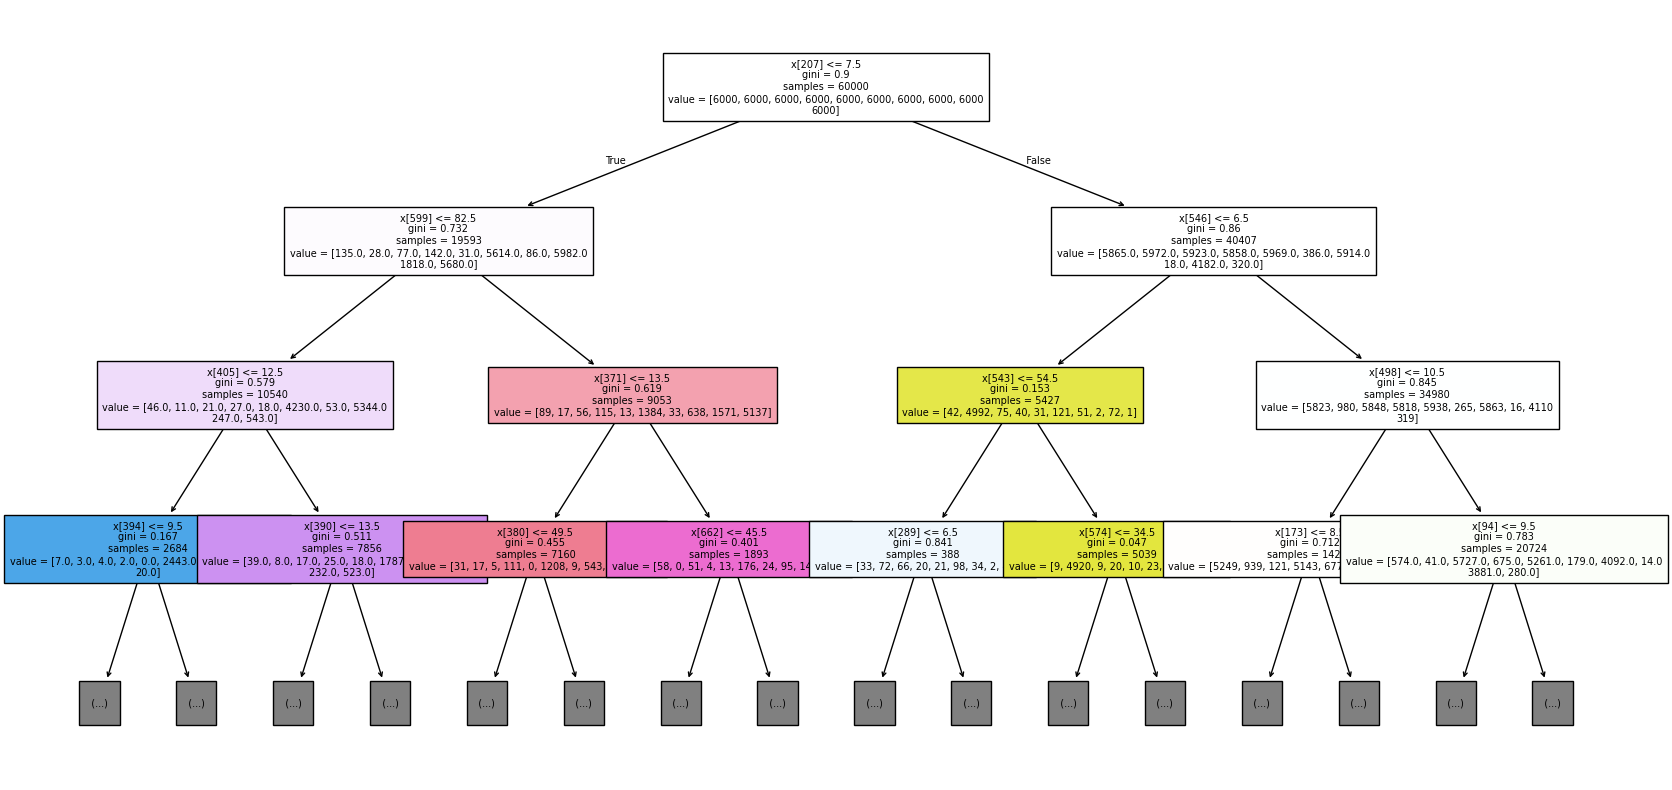

In [26]:
plt.figure(figsize=(20,10))
tree.plot_tree(Dtc,
               max_depth=3,
               filled=True,
               fontsize=7);

For Fashion MNIST, I turned each image into one long row of numbers. Then I trained a decision tree and tested how well it worked. The tree uses pixel values to split the images into groups and then predicts the clothing type for each group. I only showed part of the tree because the full one is very large.

[4]

In [27]:
Rfc = RandomForestClassifier(n_estimators=100).fit(xs_train,y_train)
Rfc

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
rf_pred = Rfc.predict(xs_test)

acc = 0
for i in range(len(rf_pred)):
    if rf_pred[i]==y_test[i]:
        acc += 1
acc/len(rf_pred)

0.8765

In [29]:
dt_pred = Dtc.predict(xs_test)

dt_acc = 0
for i in range(len(dt_pred)):
    if dt_pred[i]==y_test[i]:
        dt_acc += 1
dt_acc = dt_acc/len(dt_pred)

rf_acc = 0
for i in range(len(rf_pred)):
    if rf_pred[i]==y_test[i]:
        rf_acc += 1
rf_acc = rf_acc/len(rf_pred)

dt_acc,rf_acc

(0.7918, 0.8765)

In [30]:
pd.DataFrame({
    'model':['DecisionTreeClassifier','RandomForestClassifier'],
    'accuracy':[dt_acc,rf_acc]
})

,model,accuracy
0,DecisionTreeClassifier,0.7918
1,RandomForestClassifier,0.8765


The random forest did better than the single decision tree. This is because it combines many trees instead of relying on just one. That makes it more accurate and less likely to overfit the training data.

In [31]:
Tw = TweedieRegressor().fit(xs_train,y_train)
Tw

/Users/teddytaussig/COM328_tf/lib/python3.12/site-packages/sklearn/linear_model/_glm/glm.py:290: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


,"power power: float, default=0The power determines the underlying target distribution accordingto the following table:+-------+------------------------+| Power | Distribution |+=======+========================+| 0 | Normal |+-------+------------------------+| 1 | Poisson |+-------+------------------------+| (1,2) | Compound Poisson Gamma |+-------+------------------------+| 2 | Gamma |+-------+------------------------+| 3 | Inverse Gaussian |+-------+------------------------+For ``0 < power < 1``, no distribution exists.",0.0
,"alpha alpha: float, default=1Constant that multiplies the L2 penalty term and determines theregularization strength. ``alpha = 0`` is equivalent to unpenalizedGLMs. In this case, the design matrix `X` must have full column rank(no collinearities).Values of `alpha` must be in the range `[0.0, inf)`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the linear predictor (`X @ coef + intercept`).",True
,"link link: {'auto', 'identity', 'log'}, default='auto'The link function of the GLM, i.e. mapping from linear predictor`X @ coeff + intercept` to prediction `y_pred`. Option 'auto' setsthe link depending on the chosen `power` parameter as follows:- 'identity' for ``power <= 0``, e.g. for the Normal distribution- 'log' for ``power > 0``, e.g. for Poisson, Gamma and Inverse Gaussian distributions",'auto'
,"solver solver: {'lbfgs', 'newton-cholesky'}, default='lbfgs'Algorithm to use in the optimization problem:'lbfgs' Calls scipy's L-BFGS-B optimizer.'newton-cholesky' Uses Newton-Raphson steps (in arbitrary precision arithmetic equivalent to iterated reweighted least squares) with an inner Cholesky based solver. This solver is a good choice for `n_samples` >> `n_features`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features` because it explicitly computes the Hessian matrix. .. versionadded:: 1.2",'lbfgs'
,"max_iter max_iter: int, default=100The maximal number of iterations for the solver.Values must be in the range `[1, inf)`.",100
,"tol tol: float, default=1e-4Stopping criterion. For the lbfgs solver,the iteration will stop when ``max{|g_j|, j = 1, ..., d} <= tol``where ``g_j`` is the j-th component of the gradient (derivative) ofthe objective function.Values must be in the range `(0.0, inf)`.",0.0001
,"warm_start warm_start: bool, default=FalseIf set to ``True``, reuse the solution of the previous call to ``fit``as initialization for ``coef_`` and ``intercept_`` .",False
,"verbose verbose: int, default=0For the lbfgs solver set verbose to any positive number for verbosity.Values must be in the range `[0, inf)`.",0


In [32]:
tw_pred = Tw.predict(xs_test)
tw_pred = np.asarray(np.round(tw_pred,0),dtype=np.int8)
tw_pred = np.clip(tw_pred,0,9)
tw_pred[:20],y_test[:20]

(array([8, 3, 1, 1, 4, 1, 3, 5, 6, 7, 3, 6, 6, 4, 4, 2, 2, 4, 7, 0],
       dtype=int8),
 array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0],
       dtype=uint8))

In [33]:
tw_acc = 0
for i in range(len(tw_pred)):
    if tw_pred[i]==y_test[i]:
        tw_acc += 1
tw_acc/len(tw_pred)

0.3795

In [34]:
pd.DataFrame({
    'model':['TweedieRegressor','DecisionTreeClassifier','RandomForestClassifier'],
    'accuracy':[tw_acc,dt_acc,rf_acc]
})

,model,accuracy
0,TweedieRegressor,3795.0000
1,DecisionTreeClassifier,0.7918
2,RandomForestClassifier,0.8765
